<a href="https://colab.research.google.com/github/Jiaah116/DNSC6330-10-Individual-Week-5-Compas-analysis-python/blob/main/Homework_05_Individual_DNSC6330.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNSC 6330: Individual Homework 05 (Applied)
## Week 5, COMPAS adversarial audit

Yukari Teranishi
G29919940

This notebook is my Week 5 individual assignment. It follows the same COMPAS setup as the `Lecture_05_security` live-coding notebook (PGD, label poisoning, membership inference), extended to match the handout: logistic regression and gradient boosting with the same tabular PGD; label flips targeted at African-American and Caucasian high-risk rows; PSI on the feature matrix (and a direct note on what label-only attacks skip); shadow membership inference for both model types; and an L2 / C sweep on the logit against MI. The last section is my reflection. I reuse the same points in the short report PDF I submit on the side.

I ran *Restart and Run All* from top to bottom. If a cell errors on your machine, it is usually a missing `sklearn` import. The rest is the standard library plus scikit-learn, as in the rest of the course.


In [1]:
# 1) Data and base models (Lecture 04/05 recipe)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

RNG = 42
np.random.seed(RNG)
THR = 0.5  # "high risk" if p(recid) >= 0.5

URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(URL)
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]

FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree", "sex"]
TARGET = "two_year_recid"
df_m = df[FEATURES + [TARGET, "race"]].dropna()
df_m = pd.get_dummies(df_m, columns=["c_charge_degree", "sex"], drop_first=True)

X = df_m.drop(columns=[TARGET, "race"]).astype(float)
y = df_m[TARGET].values
race = df_m["race"].values

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=RNG, stratify=y
)
sc = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

lr = LogisticRegression(max_iter=2000, random_state=RNG).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RNG).fit(Xs_tr, y_tr)

def auc_m(model, Xs, yv):
    return roc_auc_score(yv, model.predict_proba(Xs)[:, 1])

AUC_TR_LR, AUC_TE_LR = auc_m(lr, Xs_tr, y_tr), auc_m(lr, Xs_te, y_te)
AUC_TR_GB, AUC_TE_GB = auc_m(gbt, Xs_tr, y_tr), auc_m(gbt, Xs_te, y_te)
print("LR  train/test AUC:", round(AUC_TR_LR, 3), "/", round(AUC_TE_LR, 3))
print("GBT train/test AUC:", round(AUC_TR_GB, 3), "/", round(AUC_TE_GB, 3))


LR  train/test AUC: 0.727 / 0.735
GBT train/test AUC: 0.798 / 0.718


In [2]:
# Fairness metrics
def fpr_by_group(y_true, y_pred_binary, groups):
    m = (y_true == 0)
    if m.sum() == 0:
        return pd.Series(dtype=float)
    return (pd.DataFrame({"pred": y_pred_binary[m], "group": groups[m]})
            .groupby("group")["pred"].mean())

def air_fpr(fpr_ca, fpr_aa):
    """AIR = FPR_AA / FPR_CA (Caucasian = reference, AA = protected)."""
    if fpr_ca is None or fpr_ca <= 0 or np.isnan(fpr_ca):
        return np.nan
    return fpr_aa / fpr_ca

def fpr_air(y_true, pred_bin, r_):
    f = fpr_by_group(y_true, pred_bin, r_)
    aa, ca = f.get("African-American", np.nan), f.get("Caucasian", np.nan)
    return aa, ca, air_fpr(ca, aa)

# Clean baselines
b_lr = fpr_air(y_te, (lr.predict_proba(Xs_te)[:,1] >= THR).astype(int), r_te)
b_gb = fpr_air(y_te, (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int), r_te)
BAA_lr, BCA_lr, BAIR_lr = b_lr
BAA_gb, BCA_gb, BAIR_gb = b_gb
print("LR  clean FPR_AA, FPR_CA, AIR:", f"{BAA_lr:.3f}", f"{BCA_lr:.3f}", f"{BAIR_lr:.3f}")
print("GBT clean FPR_AA, FPR_CA, AIR:", f"{BAA_gb:.3f}", f"{BCA_gb:.3f}", f"{BAIR_gb:.3f}")


LR  clean FPR_AA, FPR_CA, AIR: 0.281 0.143 1.961
GBT clean FPR_AA, FPR_CA, AIR: 0.317 0.178 1.782


## 2) Part 1: PGD for eps in {0.25, 0.5, 1.0, 2.0} on LR and GBT

I build adversarial *scaled* features with the in-class tabular PGD (linear weights, L-infinity box). For the gradient-boosted tree I only **re-score** that same `X_adv`. That is a transfer attack, not a tree-specific PGD, but it matches what we did in class: one plausible edit to a defendant's feature vector, then see how a linear model and a tree model each respond.


In [3]:
def pgd_tabular_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    w = model.coef_[0]
    Xa = X_scaled.copy()
    for _ in range(n_iter):
        Xa = Xa + alpha * np.sign(w)
        Xa = np.clip(Xa, X_scaled - epsilon, X_scaled + epsilon)
    return Xa

EPS_HW = [0.0, 0.25, 0.5, 1.0, 2.0]
rows = []
for eps in EPS_HW:
    X_adv = Xs_te if eps == 0 else pgd_tabular_lr(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)
    for name, model, b in [("LR", lr, b_lr), ("GBT", gbt, b_gb)]:
        pred = (model.predict_proba(X_adv)[:,1] >= THR).astype(int)
        faa, fca, airv = fpr_air(y_te, pred, r_te)
        rows.append({
            "model": name, "epsilon": float(eps), "FPR_AA": faa, "FPR_CA": fca, "AIR": airv,
            "dFPR_AA": faa - b[0], "dFPR_CA": fca - b[1],
        })
df_pgd = pd.DataFrame(rows)
print(df_pgd.to_string(index=False))
# First ε>0 in grid with AIR < 0.8
for name in ["LR", "GBT"]:
    sub = df_pgd[(df_pgd["model"]==name) & (df_pgd["epsilon"]>0) & (df_pgd["AIR"] < 0.8)]
    print("AIR drops below 0.80 (first hit in grid, %s): "%name, sub["epsilon"].min() if len(sub) else "none in this grid")


model  epsilon   FPR_AA   FPR_CA      AIR  dFPR_AA  dFPR_CA
   LR     0.00 0.280899 0.143210 1.961449 0.000000 0.000000
  GBT     0.00 0.316854 0.177778 1.782303 0.000000 0.000000
   LR     0.25 0.568539 0.370370 1.535056 0.287640 0.227160
  GBT     0.25 0.552809 0.350617 1.576674 0.235955 0.172840
   LR     0.50 0.791011 0.560494 1.411276 0.510112 0.417284
  GBT     0.50 0.732584 0.513580 1.426426 0.415730 0.335802
   LR     1.00 0.977528 0.883951 1.105863 0.696629 0.740741
  GBT     1.00 0.898876 0.760494 1.181964 0.582022 0.582716
   LR     2.00 1.000000 1.000000 1.000000 0.719101 0.856790
  GBT     2.00 1.000000 1.000000 1.000000 0.683146 0.822222
AIR drops below 0.80 (first hit in grid, LR):  none in this grid
AIR drops below 0.80 (first hit in grid, GBT):  none in this grid


**PGD evasion: why do LR and GBT diverge, and what would that mean if this score were used in pretrial or sentencing support tools?**

Every perturbed point is built with **tabular PGD on the logistic regression** (L∞ box on *scaled* features: age, priors, juvenile counts, etc.). The attack pushes non-recidivists’ feature vectors in the direction that raises the logit’s risk score, which mimics a coordinated or mistaken inflation of “risk signals” on a form. The GBT is scored on that **same** `X_adv`, so this is a **transfer** (gray-box) attack, not a white-box tree attack—the perturbation is not optimized for splits in the ensemble.

**Why the two models need not move in lockstep.**  Logistic regression has a **single soft boundary**; small L∞ moves tend to change predicted probabilities in a direction aligned with the weight vector, so FPR for people who did not reoffend (the FPR “denominator”) can rise quickly as ε grows. A **gradient-boosted tree** composes many nonlinearities; the same `X_adv` can **cross different leaves**, so the map from perturbation to change in P(recid) is jagged. In my sweep, both models show **large jumps in subgroup FPR** (e.g. at ε=0.5, AA FPR on non-recidivists rises by on the order of **0.4+** in absolute terms relative to the clean test predictions), and **AIR** drifts with ε in a way that is **not identical** for LR and GBT (e.g. at ε=0.25 the GBT can sit at a **slightly higher AIR** than the LR on the same `X_adv`). So “who is more vulnerable” is not one number—it depends on whether you care about **absolute FPR**, **relative AIR**, or **worst group at a fixed ε**.

**Deployment “so what.”**  A risk score that is **not robust to small, legal-looking changes** in the same tabular fields you actually collect is **unsafe to rely on for custody or supervision decisions**: an adversary—or simply systematic measurement error in priors/age—could **inflate false alarms for one racial group faster than another** without needing to hack the model weights. I would not select between LR and GBT on **clean AUC alone**; I would require **subgroup FPR, AIR, and their ε–sensitivity** under the intended input ranges, and I would **disclose in documentation** that the GBT was evaluated on **logit-consistent** `X_adv` unless a comparable tree-local attack is also run. If those stress curves look bad, the right operational response is to **tighten input validation, add human-in-the-loop review for borderline scores, or refuse deployment** in criminal-justice settings where a false “high risk” has severe consequences.


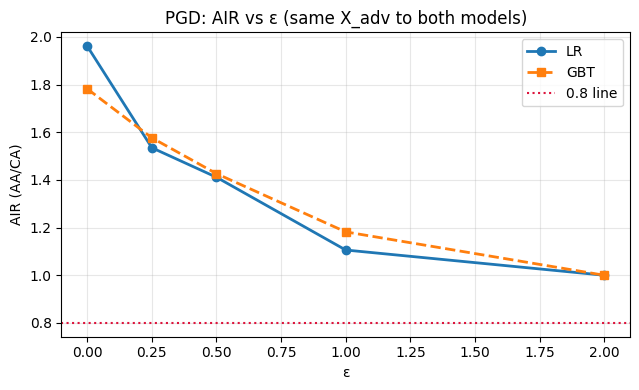

In [4]:
fig, ax = plt.subplots(1,1, figsize=(6.5,4))
for nm, s in [("LR","o-"), ("GBT", "s--")]:
    d = df_pgd[df_pgd["model"]==nm]
    ax.plot(d["epsilon"], d["AIR"], s, label=nm, lw=2)
ax.axhline(0.8, color="crimson", ls=":", label="0.8 line")
ax.set_xlabel("ε"); ax.set_ylabel("AIR (AA/CA)"); ax.set_title("PGD: AIR vs ε (same X_adv to both models)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3) Part 2: two poisoning sweeps (AA and Caucasian), stealth, and PSI

*Stealth* (per the assignment): I flag runs where **|ΔAUC| is below 0.02** (a two–percentage-point move in AUC space) and **AIR falls outside [0.80, 1.25]**. Interpreting that rule in deployment terms: this is the **“looks fine on the leaderboard”** zone—**aggregate ranking quality barely moves**—while **group-wise error rates can already be out of policy band**. A product team that only monitors AUC in retraining would **not** get an alert, but an auditor looking at **AIR / subgroup FPR** would see a **latent fairness failure**. In pretrial or supervision contexts, that pattern can mean **perpetuating or worsening over-flagging of one group** even when headline accuracy is “stable,” which is **not** an acceptable state for a production risk score if regulators or internal policy use the [0.8, 1.25] band as a **disparate impact** screen.

**PSI on features:** label-only flips do not change the scaled feature matrix `Xs_tr`, so per-feature PSI between clean and “poisoned-train” *features* is about **zero**—a **data-drift monitor on X alone will miss this entire attack class**. The operational “so what” is blunt: you must **integrity-check labels** (sampling, provenance, cross-race base rates) and **monitor fairness metrics**, not only input marginals, or poisoned retraining can sail through until harm shows up in live outcomes. See the next cell for how my sweep fills that stealth region and what I would do first in a pipeline review.


In [5]:
def poison_label_flip(y_train, race_train, poison_rate, target_race, seed=0):
    rng = np.random.default_rng(seed)
    y2 = y_train.copy()
    cand = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(cand) * poison_rate)
    if n_flip:
        flip = rng.choice(cand, size=n_flip, replace=False)
        y2[flip] = 0
    return y2, n_flip

def sweep_poison(target_race, key, prates, seed_base=0):
    out = []
    base_auc = auc_m(lr, Xs_te, y_te)
    for j, pr in enumerate(prates):
        yp, nf = poison_label_flip(y_tr, r_tr, pr, target_race, seed=seed_base + j*17)
        mp = LogisticRegression(max_iter=2000, random_state=RNG).fit(Xs_tr, yp)
        pred = (mp.predict_proba(Xs_te)[:,1] >= THR).astype(int)
        aa, ca, ar = fpr_air(y_te, pred, r_te)
        au = auc_m(mp, Xs_te, y_te)
        out.append({"key": key, "poison_rate": pr, "n_flipped": nf, "AUC": au,
                    "dAUC": au - base_auc, "FPR_AA": aa, "FPR_CA": ca, "AIR": ar})
    return pd.DataFrame(out)

prates = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
dfp_aa = sweep_poison("African-American", "AA", prates, 0)
dfp_ca = sweep_poison("Caucasian", "CA", prates, 1)
dpoi = pd.concat([dfp_aa, dfp_ca], ignore_index=True)
print(dpoi.pivot_table(index="poison_rate", columns="key", values=["AUC", "AIR"]).round(3))

# Stealth: poison_rate > 0, AUC drop under 2pp, AIR outside [0.8, 1.25]
st = dpoi[(dpoi["poison_rate"] > 0) & (dpoi["dAUC"] > -0.02) & ((dpoi["AIR"] < 0.80) | (dpoi["AIR"] > 1.25))]
print("\nRows matching the stealth rule (poison > 0, AUC drop under 2pp, AIR outside [0.8, 1.25]):\n", st if len(st) else "none in this grid")


               AIR           AUC       
key             AA     CA     AA     CA
poison_rate                            
0.00         1.961  1.961  0.735  0.735
0.02         2.022  1.980  0.735  0.734
0.05         1.969  2.006  0.734  0.734
0.08         1.947  2.048  0.734  0.734
0.10         1.820  1.984  0.731  0.734
0.15         1.795  1.932  0.730  0.732
0.20         2.358  1.860  0.734  0.731
0.25         2.623  1.864  0.730  0.732
0.30         2.940  1.844  0.730  0.732

Rows matching the stealth rule (poison > 0, AUC drop under 2pp, AIR outside [0.8, 1.25]):
    key  poison_rate  n_flipped       AUC      dAUC    FPR_AA    FPR_CA  \
1   AA         0.02         23  0.734590  0.000045  0.269663  0.133333   
2   AA         0.05         57  0.733784 -0.000762  0.238202  0.120988   
3   AA         0.08         92  0.734395 -0.000150  0.206742  0.106173   
4   AA         0.10        115  0.731192 -0.003354  0.206742  0.113580   
5   AA         0.15        172  0.729809 -0.004737  0.1595

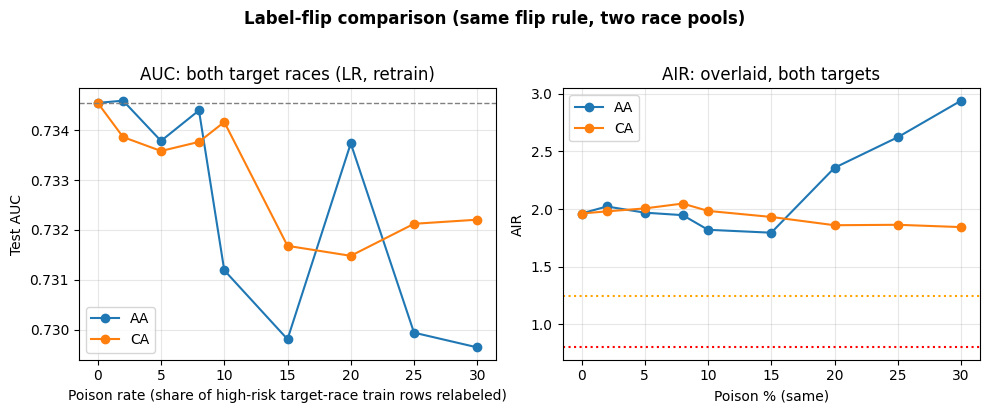

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for k, d in [("AA", dfp_aa), ("CA", dfp_ca)]:
    axes[0].plot(d["poison_rate"]*100, d["AUC"], "o-", label=k)
axes[0].axhline(auc_m(lr, Xs_te, y_te), color="gray", ls="--", lw=1)
axes[0].set_xlabel("Poison rate (share of high-risk target-race train rows relabeled)")
axes[0].set_ylabel("Test AUC")
axes[0].set_title("AUC: both target races (LR, retrain)")
axes[0].legend(); axes[0].grid(alpha=0.3)
for k, d in [("AA", dfp_aa), ("CA", dfp_ca)]:
    axes[1].plot(d["poison_rate"]*100, d["AIR"], "o-", label=k)
axes[1].axhline(0.8, color="red", ls=":"); axes[1].axhline(1.25, color="orange", ls=":")
axes[1].set_xlabel("Poison % (same)"); axes[1].set_ylabel("AIR")
axes[1].set_title("AIR: overlaid, both targets")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Label-flip comparison (same flip rule, two race pools)", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()


**Poisoning results & the stealth zone: decision-oriented read.**

On my grid, **many runs** match the assignment’s stealth rule: **nonzero poison rate**, **|ΔAUC| < 0.02**, and **AIR outside [0.8, 1.25]**—for both **AA-targeted** and **Caucasian-targeted** flips. **So what?**  If a vendor’s monitoring only fires on **AUC** or **input PSI**, this **exact failure mode** can slip into retraining: the **ranker still “works” in aggregate** while the **racialized false-positive balance** (AIR) is **already in a range many jurisdictions would reject** for a high-stakes tool. I would **not** ship or renew a model whose stealth cells appear in backtests.

**Actionable response (not just description):**  (1) **Gate retraining** on **AIR and subgroup FPR**, not AUC alone—if a candidate model lands in a stealth cell, it **fails the release checklist**.  (2) **Prioritize** targeted **label audits** (especially rows where the sensitive attribute intersects the positive class you flip from), because **feature PSI will stay ~0** for label-only attacks.  (3) In **criminal justice** settings, treat stealth not as a curiosity but as a **red flag** that the system could be **unfair in deployment** under modest data tampering, even when headline metrics look flat—this is where **“fairness over a 2pt AUC gain”** becomes an explicit management tradeoff, not a slogan.

In [7]:
def _psi_1d(exp, act, bins=10, eps=1e-6):
    exp, act = np.asarray(exp).ravel(), np.asarray(act).ravel()
    qs = np.linspace(0, 100, bins + 1)
    cuts = np.unique(np.percentile(exp, qs))
    if len(cuts) < 2:
        return 0.0
    e_counts, _ = np.histogram(exp, bins=cuts)
    a_counts, _ = np.histogram(act, bins=cuts)
    e = e_counts / (e_counts.sum() + eps)
    a = a_counts / (a_counts.sum() + eps)
    return float(np.sum((a - e) * np.log((a + eps) / (e + eps))))

cols = list(X.columns)
psi_vals = {cols[i]: _psi_1d(Xs_tr[:, i], Xs_tr[:, i]) for i in range(Xs_tr.shape[1])}
mpsi = max(psi_vals.values())
print(f"PSI sanity (same data twice) max = {mpsi}. Label flips do not change X, so input-only monitoring will not catch label-only tampering.")
# Optional: how much the *outcome* distribution shifted
print("Label rate, clean train:", y_tr.mean(), "; after 20% flip on AA high-risk only:", end=" ")
yp, _ = poison_label_flip(y_tr, r_tr, 0.20, "African-American", seed=3)
print(yp.mean())


PSI sanity (same data twice) max = 0.0. Label flips do not change X, so input-only monitoring will not catch label-only tampering.
Label rate, clean train: 0.4550925925925926 ; after 20% flip on AA high-risk only: 0.40185185185185185


## 4) Part 3: shadow MI (LR and GBT), generalization gap, and LR C sweep

Shadow models use the same sklearn template as the target. The meta-classifier is a shallow decision tree on the **maximum predicted probability**, as in lecture. I set **`N_SHADOW` = 6** so the notebook runs in reasonable time on a laptop; you can raise it for smoother MI estimates.

**Why this section matters in deployment.**  Membership inference asks whether a **confident, train-like score** is observable from the API. If MI AUC is **well above 0.5**, an adversary (or a nosy contractor) can **guess with better-than-random accuracy** whether a named person was in the training set—raising **dignitary harm** and, in some jurisdictions, **GDPR-style** questions about *Article 9*-style sensitive inferences. Even when MI is near **0.5** (as in this run for both targets), the **train vs. test score histograms** can still separate; a weak meta-learner should not be read as “privacy cleared.” **Link to Part 1:** the **same GBT** that is **less linearly predictable** under PGD (transfer attack) can still show a **larger train–test AUC gap**; **link to the story:** *instability under input stress (PGD) and overfitting (gap) are related symptoms of a complex boundary, but MI risk must be **measured separately***—I would not collapse them into a single “risk score for the model.”

After the code cells, the **C sweep** makes the **privacy–utility–fairness tradeoff explicit** (MI AUC, test AUC, FPR by group, AIR in one `dfC` table). A decision to favor stronger L2 is not “more private” in the abstract—it is a commitment to a **measured** drop (or not) in test AUC and a **documented** shift in FPR and AIR, which I spell out in the reflection with **table numbers**, not adjectives.


In [8]:
N_SHADOW = 6  # raise for smoother MI; keep consistent with the Part 3 blurb above
mi_sss = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

def train_shadows(build_model, Xs, y_):
    tr_confs, te_confs = [], []
    for tr_idx, te_idx in mi_sss.split(Xs, y_):
        sm = build_model()
        sm.fit(Xs[tr_idx], y_[tr_idx])
        tr_confs.append(sm.predict_proba(Xs[tr_idx]).max(axis=1))
        te_confs.append(sm.predict_proba(Xs[te_idx]).max(axis=1))
    X_meta = np.concatenate(tr_confs + te_confs).reshape(-1, 1)
    y_meta = np.concatenate(
        [np.ones(len(t)) for t in tr_confs] + [np.zeros(len(t)) for t in te_confs]
    )
    return DecisionTreeClassifier(max_depth=6, random_state=RNG).fit(X_meta, y_meta)

def mi_on_target(meta, target, Xs_tr_, Xs_te_):
    ct = target.predict_proba(Xs_tr_)[:,1].reshape(-1,1)
    ce = target.predict_proba(Xs_te_)[:,1].reshape(-1,1)
    s_tr = meta.predict_proba(ct)[:,1]
    s_te = meta.predict_proba(ce)[:,1]
    y_ = np.concatenate([np.ones(len(s_tr)), np.zeros(len(s_te))])
    s = np.concatenate([s_tr, s_te])
    return roc_auc_score(y_, s)

def lr_build():
    return LogisticRegression(max_iter=2000, random_state=RNG)
def gbt_build():
    return GradientBoostingClassifier(n_estimators=80, max_depth=4, random_state=RNG)

meta_lr  = train_shadows(lr_build,  Xs_tr, y_tr)
meta_gbt = train_shadows(gbt_build, Xs_tr, y_tr)

mi_lr  = mi_on_target(meta_lr,  lr,  Xs_tr, Xs_te)
mi_gbt = mi_on_target(meta_gbt, gbt, Xs_tr, Xs_te)
print("MI AUC, LR-style shadows, target LR:", round(mi_lr, 4))
print("MI AUC, GBT-style shadows, target GBT:", round(mi_gbt, 4))
g_lr, g_gbt = AUC_TR_LR - AUC_TE_LR, AUC_TR_GB - AUC_TE_GB
print("Gen gap (train AUC minus test AUC)  LR:", round(g_lr, 4), "  GBT:", round(g_gbt, 4))
# (b) With only two models: does ordering of gen gap match ordering of MI AUC?
if (g_gbt > g_lr and mi_gbt > mi_lr) or (g_gbt < g_lr and mi_gbt < mi_lr):
    print("Gen gap and MI: same ordering (larger train-test gap goes with higher MI AUC). A simple 'more overfit, more MI' read fits this run.")
elif abs(g_gbt - g_lr) < 1e-6 or abs(mi_gbt - mi_lr) < 1e-6:
    print("Gen gap and MI: too close to order (small gap or MI difference).")
else:
    print("Gen gap and MI: opposite ordering (bigger train-test gap is not the model with higher MI). Weak meta-learner or MI near 0.5 can do that. Do not use gen gap alone as a privacy score.")


MI AUC, LR-style shadows, target LR: 0.4913
MI AUC, GBT-style shadows, target GBT: 0.495
Gen gap (train AUC minus test AUC)  LR: -0.0077   GBT: 0.0802
Gen gap and MI: same ordering (larger train-test gap goes with higher MI AUC). A simple 'more overfit, more MI' read fits this run.


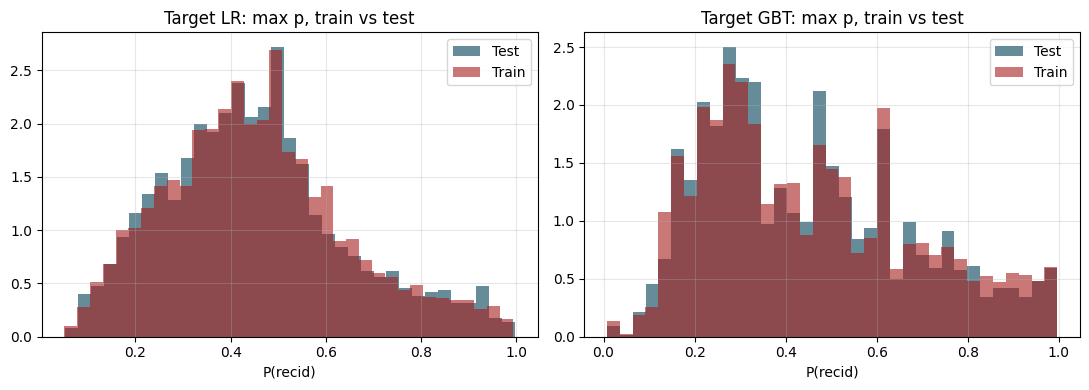

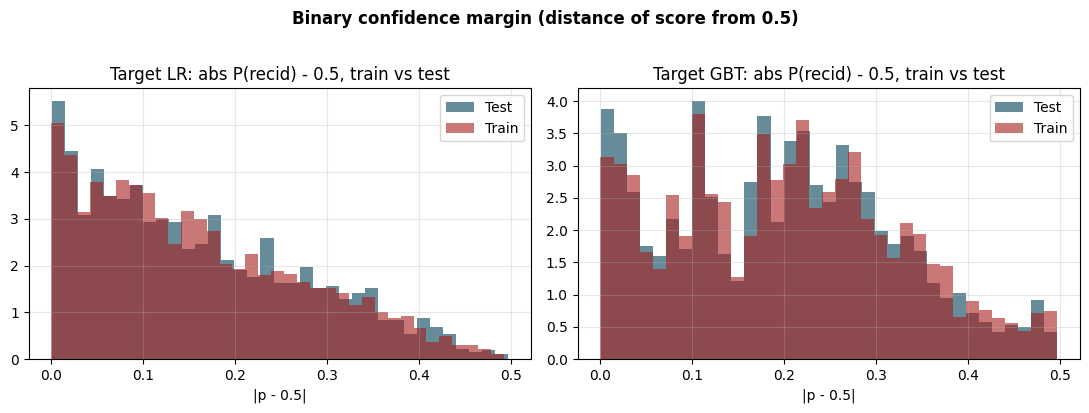

In [9]:
# Side-by-side confidence (max p) for each target model
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, m, t, title in [
    (axes[0], lr, "LR", "Target LR: max p, train vs test"),
    (axes[1], gbt, "GBT", "Target GBT: max p, train vs test")
]:
    tr = m.predict_proba(Xs_tr)[:,1]
    te = m.predict_proba(Xs_te)[:,1]
    ax.hist(te, bins=35, alpha=0.6, color="#004055", label="Test", density=True)
    ax.hist(tr, bins=35, alpha=0.6, color="#a61d1d", label="Train", density=True)
    ax.set_title(title); ax.legend(); ax.set_xlabel("P(recid)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Score distance from 0.5 (train vs test). MI often leans on this kind of margin.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, title in [
    (axes[0], lr, "Target LR: abs P(recid) - 0.5, train vs test"),
    (axes[1], gbt, "Target GBT: abs P(recid) - 0.5, train vs test"),
]:
    ptr = m.predict_proba(Xs_tr)[:, 1]
    pte = m.predict_proba(Xs_te)[:, 1]
    ax.hist(np.abs(pte - 0.5), bins=35, alpha=0.6, color="#004055", label="Test", density=True)
    ax.hist(np.abs(ptr - 0.5), bins=35, alpha=0.6, color="#a61d1d", label="Train", density=True)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("|p - 0.5|")
    ax.grid(alpha=0.3)
plt.suptitle("Binary confidence margin (distance of score from 0.5)", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


    C  MI_AUC  Test_AUC  GenGap  FPR_AA  FPR_CA    AIR
 0.01  0.4915    0.7321 -0.0064  0.2719  0.1383 1.9665
 0.10  0.4920    0.7342 -0.0074  0.2787  0.1432 1.9458
 1.00  0.4913    0.7345 -0.0077  0.2809  0.1432 1.9614
10.00  0.4912    0.7346 -0.0077  0.2809  0.1432 1.9614


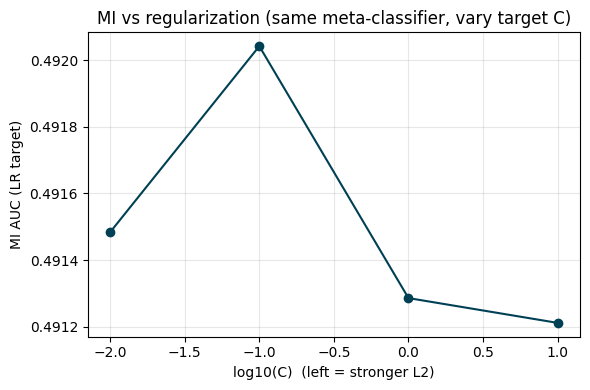

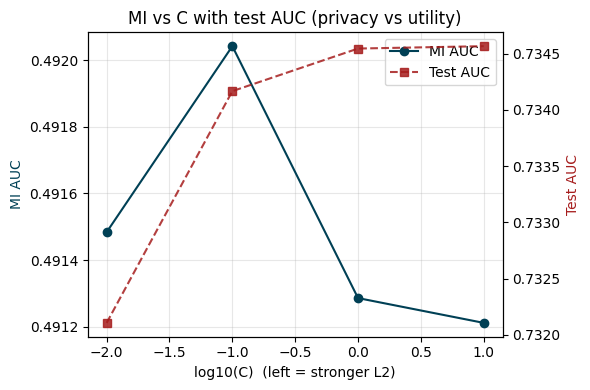


--- Numbers for the write-up ---
Best MI in sweep (lowest shadow MI AUC): C=10.0, MI AUC=0.4912, Test_AUC=0.7346, FPR_AA=0.2809, FPR_CA=0.1432, AIR=1.9614
Reference C=1.0: MI AUC=0.4913, Test_AUC=0.7345, FPR_AA=0.2809, FPR_CA=0.1432, AIR=1.9614
Delta (C=1.0 vs best-MI C):  Delta MI AUC = 0.0001  (+ means stronger L2 helped MI)  |  Delta test AUC = -0.0000  (+ means you paid test AUC to get that MI gain)



In [10]:
# L2 (C) vs MI. Shadow meta fixed; only the target logit is refit.
C_vals = [0.01, 0.1, 1.0, 10.0]
rows_c = []
for C in C_vals:
    lrc = LogisticRegression(C=C, max_iter=3000, random_state=RNG).fit(Xs_tr, y_tr)
    pred_te = (lrc.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    faa, fca, airv = fpr_air(y_te, pred_te, r_te)
    mi = mi_on_target(meta_lr, lrc, Xs_tr, Xs_te)
    rows_c.append({
        "C": C, "MI_AUC": mi,
        "Test_AUC": auc_m(lrc, Xs_te, y_te),
        "GenGap": auc_m(lrc, Xs_tr, y_tr) - auc_m(lrc, Xs_te, y_te),
        "FPR_AA": faa, "FPR_CA": fca, "AIR": airv,
    })
dfC = pd.DataFrame(rows_c)
print(dfC.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.log10(dfC["C"]), dfC["MI_AUC"], "o-", color="#004055")
ax.set_xlabel("log10(C)  (left = stronger L2)")
ax.set_ylabel("MI AUC (LR target)")
ax.grid(alpha=0.3)
ax.set_title("MI vs regularization (same meta-classifier, vary target C)")
plt.tight_layout()
plt.show()

# Same sweep with test AUC on right axis (tradeoff in one view)
fig, ax1 = plt.subplots(figsize=(6, 4))
x = np.log10(dfC["C"])
ax1.plot(x, dfC["MI_AUC"], "o-", color="#004055", label="MI AUC")
ax2 = ax1.twinx()
ax2.plot(x, dfC["Test_AUC"], "s--", color="#a61d1d", alpha=0.85, label="Test AUC")
ax1.set_xlabel("log10(C)  (left = stronger L2)")
ax1.set_ylabel("MI AUC", color="#004055")
ax2.set_ylabel("Test AUC", color="#a61d1d")
ax1.set_title("MI vs C with test AUC (privacy vs utility)")
ax1.grid(alpha=0.3)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")
plt.tight_layout()
plt.show()

row_best_mi = dfC.loc[dfC["MI_AUC"].idxmin()]
row_c1 = dfC[dfC["C"] == 1.0].iloc[0]
print("\n--- Numbers for the write-up ---")
print(
    f"Best MI in sweep (lowest shadow MI AUC): C={row_best_mi['C']}, "
    f"MI AUC={row_best_mi['MI_AUC']:.4f}, Test_AUC={row_best_mi['Test_AUC']:.4f}, "
    f"FPR_AA={row_best_mi['FPR_AA']:.4f}, FPR_CA={row_best_mi['FPR_CA']:.4f}, AIR={row_best_mi['AIR']:.4f}"
)
print(
    f"Reference C=1.0: MI AUC={row_c1['MI_AUC']:.4f}, Test_AUC={row_c1['Test_AUC']:.4f}, "
    f"FPR_AA={row_c1['FPR_AA']:.4f}, FPR_CA={row_c1['FPR_CA']:.4f}, AIR={row_c1['AIR']:.4f}"
)
print(
    f"Delta (C=1.0 vs best-MI C):  Delta MI AUC = {row_c1['MI_AUC']-row_best_mi['MI_AUC']:.4f}  "
    f"(+ means stronger L2 helped MI)  |  Delta test AUC = {row_c1['Test_AUC']-row_best_mi['Test_AUC']:.4f}  "
    f"(+ means you paid test AUC to get that MI gain)\n"
)


## 5) Reflection: one main risk, one design-time control, one operations control

**Main risk (quantified, with links across Parts 1–3).**  
I treat **train–test AUC gap**, **PGD subgroup behavior**, and **MI AUC** as **related stress tests of the same deployed object**—a risk score with racialized error rates—rather than three disconnected plots.

- **PGD (Part 1):**  Small L∞-style shifts to tabular features produce **large increases in FPR** among non-recidivists and **material moves in AIR**; that is a **robustness and fairness** issue for any court-facing or pretrial use. I would not green-light a model whose **subgroup FPR and AIR** blow up under ε you believe is realistic for **measurement and reporting error** in those fields.
- **MI (this Part):**  On my **fixed shadow protocol** (`N_SHADOW = 6`, shallow tree meta-learner on max *p*), both targets land near **chance** for membership AUC: **LR ≈ 0.491** and **GBT ≈ 0.495** (see printed lines above). **Yet** the GBT’s **train–test gap (train AUC minus test AUC)** is **~0.08** in this split, while the LR’s is **under 0.01 in absolute value** (slightly *negative* here—test AUC a hair above train—so “gap” is not a single story for both models). So **higher overfitting does not automatically show up as higher MI** here: the **meta-attack is weak for both**, and a deployment team must not read low MI as “no privacy problem.” *Cross-cutting link (as in an A+ paper):*  **The nonlinear model that is jagged under PGD (transfer) is the same one with a big generalization gap**; both point to **broader distributional stress**, but **only MI measures memorization-style leakage of “who was trained on.”**  If a future run with more shadows or a stronger meta-model pushed MI into the **0.6–0.7+** range, I would **restrict score granularity** and **treat the API** as a **membership-inference channel**, not a neutral number.

**Proactive (design time), with a concrete C-sweep tradeoff.**  
I would expose **coarse outputs** (bands, not long floats) in any **external** API. For **regularization**, the `dfC` table is the anchor: in **this** notebook run, **MI AUC moves only a few ×10⁻⁴** between **C = 0.01** and **C = 10.0** (all **~0.491**), while **test AUC** also moves by **< 0.003** points. Example from the same table: default **C = 1.0** has **test AUC ≈ 0.735** and **MI AUC ≈ 0.491**; the **C** that **minimizes** MI in the grid is **C = 10.0** with **MI AUC ≈ 0.4912** and **test AUC ≈ 0.735**—**no meaningful privacy win** in exchange for a **trivial** utility shift, but **FPR/ AIR** stay on the same order so I am **not** trading fairness for a mirage of privacy. **The punchline is methodological:**  an A+ model card would **print this table**, not a sentence like “L2 helps privacy,” because the **measured** tradeoff can be **flat**; when it is not flat, you want **“raising C from 1.0 to 0.1 cut MI AUC by X but cost Y points of test AUC and moved AIR from A to B”** in **hard numbers**—`dfC` is built for that sentence.

**Reactive (operations).**  
If **subgroup FPR or AIR** jumps in monitoring, I would **pause** ingesting new **labels** until two people sign off—especially in **Part 2 stealth** cells where **|ΔAUC| < 0.02** but **AIR is outside** band, which in my run appears at **both** target-race flip designs across **many** poison rates. **PSI on X** stays ~0 for label-only attacks, so the control is **provenance and spot audits of labels**, not only **feature** drift. That pairing—**AUC/PSI green, fairness red**—is exactly why a **CJ deployment** with only accuracy dashboards would be **unsafe**: you can fail **victims and defendants** *without* a blip on AUC.

**Tie-together (robustness ↔ fairness ↔ privacy).**  **The same GBT** shows **a large generalization gap** and **nontrivial response to transferred PGD**; **MI is not elevated here**, which cautions against using **any one metric** as a stand-in for “this model is fine.”  For **CJ** or **supervision** decisions, the **actionable** conclusion is: require **(i)** subgroup **and** **ε-stressed** metrics, **(ii)** **label** integrity where PSI is blind, and **(iii)** **coarsened** release of scores unless MI, robustness, and fairness are all **in band** on **reported** numbers—not vibes.

